In [3]:
from scipy.io import loadmat

data = loadmat(r"C:\Users\Luchitha\Documents\BCI\Hackathon\data\P1_pre_training.mat")

print(data.keys())  # see variables inside

fs = float(data['fs'].squeeze())  # sampling frequency
print(f"Sampling Frequency: {fs} Hz")
y = data['y']  # labels
print(f"Labels shape: {y.shape}")
trig= data['trig']  # trigger information   trigger is the actual time when the stimulus was presented, and it is used to segment the EEG data into epochs corresponding to each stimulus presentation.  1 - left hand trigger , -1 - right hand trigger
print(f"Trigger shape: {trig.shape}")

for key, value in data.items():
    print(key, type(value), getattr(value, 'shape', None))


dict_keys(['__header__', '__version__', '__globals__', 'fs', 'trig', 'y'])
Sampling Frequency: 256.0 Hz
Labels shape: (271816, 16)
Trigger shape: (271816, 1)
__header__ <class 'bytes'> None
__version__ <class 'str'> None
__globals__ <class 'list'> None
fs <class 'numpy.ndarray'> (1, 1)
trig <class 'numpy.ndarray'> (271816, 1)
y <class 'numpy.ndarray'> (271816, 16)


In [97]:
import numpy as np

print("EEG data array y shape:", y.shape)
print("EEG data type:", y.dtype)
print("Trigger array trig shape:", trig.shape)
print("Trigger unique labels:", np.unique(trig))
print("First 20 trigger values:", trig.flatten()[500:520])

EEG data array y shape: (271816, 16)
EEG data type: float64
Trigger array trig shape: (271816, 1)
Trigger unique labels: [-1  0  1]
First 20 trigger values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Creating RawArray with float64 data, n_channels=16, n_times=271816
    Range : 0 ... 271815 =      0.000 ...  1061.777 secs
Ready.
<RawArray | 16 x 271816 (1061.8 s), ~33.2 MiB, data loaded>
Raw info channel count: 16
Raw duration (s): 1061.77734375
Labels shape: (271816,)
Unique labels: [-1  0  1]


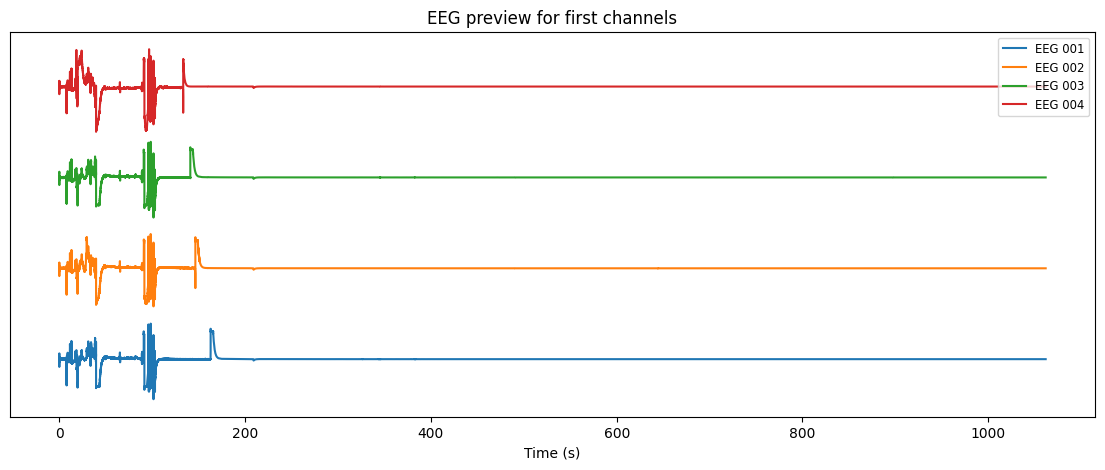

In [98]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Prepare EEG data for MNE: RawArray expects shape (n_channels, n_times)
eeg = y
if eeg.ndim != 2:
    raise ValueError(f"Expected y to be 2D EEG data, got shape {eeg.shape}")

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

n_channels, n_times = eeg.shape   
ch_names = [f"EEG {i+1:03d}" for i in range(n_channels)]
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types='eeg')
raw = mne.io.RawArray(eeg, info)

print(raw)
print("Raw info channel count:", raw.info['nchan'])
print("Raw duration (s):", raw.times[-1])

labels = trig.flatten()
print("Labels shape:", labels.shape)
print("Unique labels:", np.unique(labels))

plt.figure(figsize=(14, 5))
for idx in range(min(4, n_channels)):
    offset = idx * np.max(np.abs(eeg)) * 2
    plt.plot(raw.times, eeg[idx] + offset, label=ch_names[idx])

plt.xlabel('Time (s)')
plt.title('EEG preview for first channels')
plt.yticks([])
plt.legend(loc='upper right', fontsize='small')
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge

C:\Users\Luchitha\AppData\Local\Temp\ipykernel_17024\1192917593.py:15: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=60, show=False)


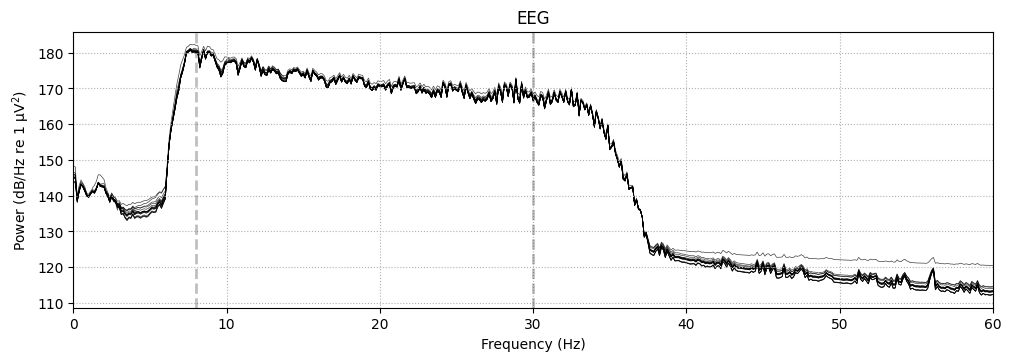

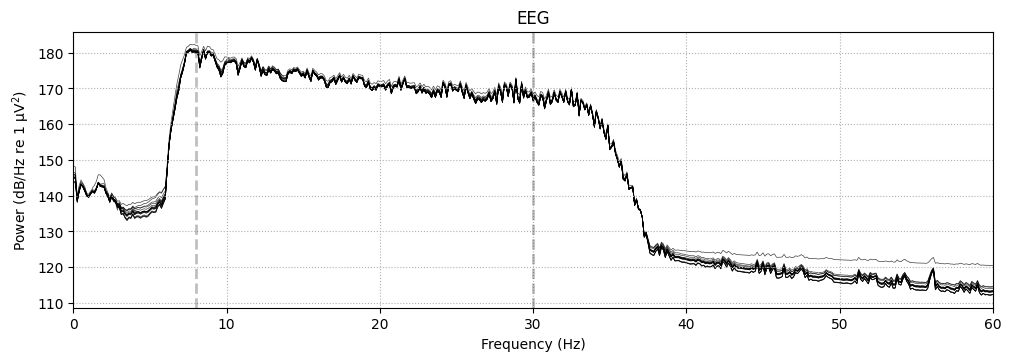

In [99]:
# Apply notch and bandpass filtering to the raw data
# Notch filter to remove power line noise (assuming 50 Hz)


raw.notch_filter([50], fir_design='firwin')

# Bandpass filter for EEG (1-40 Hz)
raw.filter(l_freq=8, h_freq=30, fir_design='firwin')

print("Filtering applied:")
print(f"Notch filter at 50 Hz")
print(f"Bandpass filter: 8-30 Hz")

# Plot power spectral density before and after filtering (optional)
raw.plot_psd(fmax=60, show=False)

Detected 80 events
Event ID mapping: {'left': 1, 'right': 2}
First 10 events:
 [[65838     0     2]
 [68312     0     2]
 [70768     0     2]
 [73224     0     2]
 [75688     0     2]
 [78019     0     1]
 [80608     0     2]
 [83032     0     1]
 [85534     0     2]
 [88008     0     1]]
Not setting metadata
80 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 80 events and 308 original time points ...
0 bad epochs dropped
<Epochs | 80 events (all good), -0.199 – 1 s (baseline -0.199 – 0 s), ~3.0 MiB, data loaded,
 'left': 40
 'right': 40>
Epochs per class:
left 40
right 40


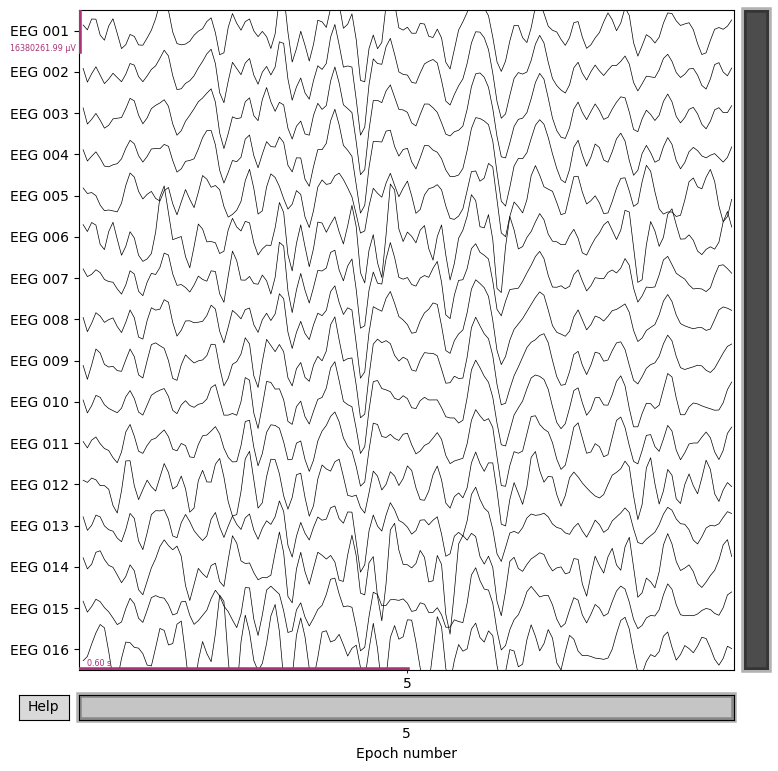

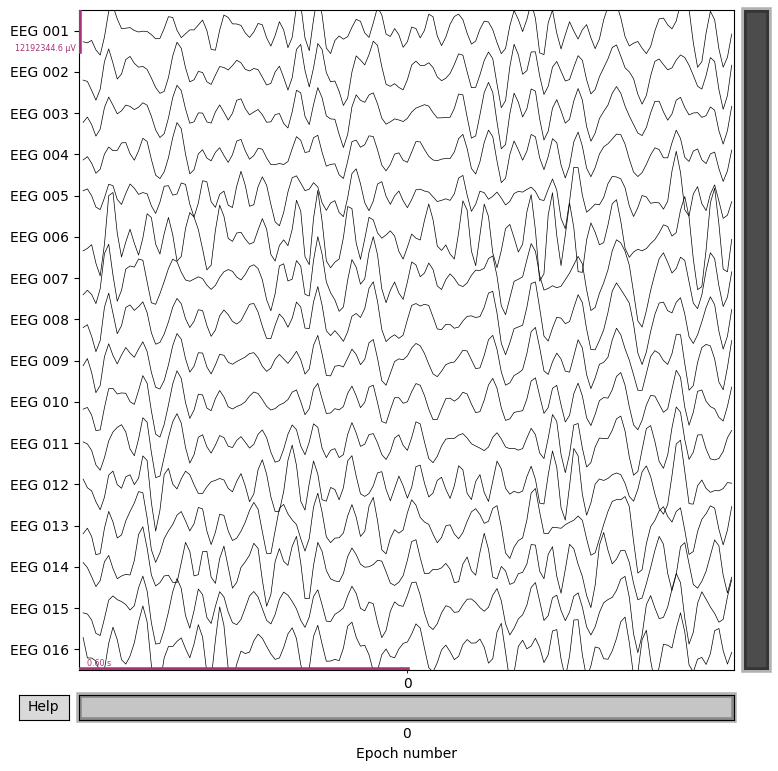

In [ ]:
# Convert trig into MNE events and epoch the EEG signal
labels = trig.flatten()
if labels.shape[0] != n_times:
    raise ValueError(f"Trigger length {labels.shape[0]} does not match EEG time samples {n_times}")

# Detect event onsets where label changes from 0 to non-zero (or first sample is non-zero)
onset_mask = np.concatenate(([labels[0] != 0], (labels[1:] != labels[:-1]) & (labels[1:] != 0)))
event_samples = np.flatnonzero(onset_mask)

event_codes = labels[event_samples]
# Map true labels to positive event IDs for MNE
event_id = {
    'left': 1,
    'right': 2,
}
label_to_event = {
    1: event_id['left'],
    -1: event_id['right'],
}

mne_events = np.column_stack((event_samples, np.zeros_like(event_samples, dtype=int), [label_to_event[int(code)] for code in event_codes]))
print(f"Detected {len(mne_events)} events")
print("Event ID mapping:", event_id)
print("First 10 events:\n", mne_events[:10])

# Epochs around events (customize tmin/tmax as needed)
tmin, tmax = -0.2, 1.0  # 200 ms before to 1000 ms after event onset
epochs = mne.Epochs(raw, mne_events, event_id=event_id, tmin=tmin, tmax=tmax, baseline=(None, 0), preload=True)






print(epochs)
print("Epochs per class:")
for name, code in event_id.items():
    print(name, len(epochs[name]))

# Plot the first epoch of each class as a sanity check
for label_name in epochs.event_id:
    if len(epochs[label_name]) > 0:
        epochs[label_name][0].plot(scalings='auto', show=False, title=f'First epoch for {label_name}')


In [102]:
# Apply Common Average Reference (CAR) - standard EEG preprocessing
X = epochs.get_data()          # shape: (n_trials, n_channels, n_times)
y = epochs.events[:, -1]       # class labels

# Apply Common Average Reference (CAR) normalization
X_car = X - X.mean(axis=1, keepdims=True)

print("Data shape:", X.shape)
print("Class labels:", np.unique(y, return_counts=True))
print("\nAfter CAR:")
print(f"  Mean across channels (should be ~0): {X_car.mean(axis=1).mean():.6f}")
print(f"  Original X mean: {X.mean():.4f}, CAR X mean: {X_car.mean():.4f}")

Data shape: (80, 16, 308)
Class labels: (array([1, 2]), array([40, 40]))

After CAR:
  Mean across channels (should be ~0): 0.000000
  Original X mean: -0.0276, CAR X mean: -0.0000


In [103]:
# Artifact detection and epoch rejection
# Reject epochs with excessive variance (potential artifacts)
var_threshold = np.percentile(X_car.var(axis=2).max(axis=1), 95)
artifact_mask = X_car.var(axis=2).max(axis=1) < var_threshold
n_rejected = (~artifact_mask).sum()

X_clean = X_car[artifact_mask]
y_clean = y[artifact_mask]

print(f"Artifact rejection:")
print(f"  Rejected {n_rejected} out of {len(y)} epochs ({100*n_rejected/len(y):.1f}%)")
print(f"  Remaining epochs: {len(y_clean)}")
print(f"  Classes in clean data: {np.unique(y_clean, return_counts=True)}")

# Z-score normalization per channel per trial (robust preprocessing)
X_normalized = np.zeros_like(X_clean)
for trial_idx in range(X_clean.shape[0]):
    for ch_idx in range(X_clean.shape[1]):
        signal = X_clean[trial_idx, ch_idx, :]
        X_normalized[trial_idx, ch_idx, :] = (signal - signal.mean()) / (signal.std() + 1e-8)

print(f"\nZ-score normalization applied:")
print(f"  Mean: {X_normalized.mean():.6f}, Std: {X_normalized.std():.6f}")

Artifact rejection:
  Rejected 4 out of 80 epochs (5.0%)
  Remaining epochs: 76
  Classes in clean data: (array([1, 2]), array([36, 40]))

Z-score normalization applied:
  Mean: -0.000000, Std: 1.000000


In [104]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

# ============ Advanced Filtering & Feature Extraction ============

# 1. Bandpass filtering in classical EEG bands
from mne.filter import filter_data

bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 40),
}

# Apply band-specific filtering and extract power features
X_band_features = []
for band_name, (l_freq, h_freq) in bands.items():
    X_band = filter_data(X_normalized, sfreq=fs, l_freq=l_freq, h_freq=h_freq, verbose=0)
    # Extract power (variance) in each band
    band_power = (X_band ** 2).mean(axis=2)  # shape: (n_trials, n_channels)
    X_band_features.append(band_power)

X_band_features = np.hstack(X_band_features)  # shape: (n_trials, n_channels * n_bands)
print(f"Band-wise power features shape: {X_band_features.shape}")
print(f"  Features per channel: {len(bands)}")

# 2. Log variance normalization (often used in BCI)
X_log_var = np.log(X_normalized.var(axis=2) + 1e-8)
print(f"Log variance features shape: {X_log_var.shape}")

# ============ Build Enhanced Classification Pipeline ============

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# Pipeline 1: CSP + LDA (baseline)
print("\n" + "="*60)
print("PIPELINE 1: CSP + LDA (Baseline)")
print("="*60)
csp = CSP(n_components=10, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf1 = Pipeline([("csp", csp), ("lda", lda)])
scores1 = cross_val_score(clf1, X_normalized, y_clean, cv=cv, scoring='accuracy')
results['CSP+LDA (normalized)'] = scores1
print(f"Accuracy: {scores1.mean():.4f} (+/- {scores1.std():.4f})")

# Pipeline 2: CSP + StandardScaler + LDA
print("\n" + "="*60)
print("PIPELINE 2: CSP + StandardScaler + LDA")
print("="*60)
csp = CSP(n_components=10, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf2 = Pipeline([
    ("csp", csp),
    ("scaler", StandardScaler()),
    ("lda", lda)
])
scores2 = cross_val_score(clf2, X_normalized, y_clean, cv=cv, scoring='accuracy')
results['CSP+Scaler+LDA'] = scores2
print(f"Accuracy: {scores2.mean():.4f} (+/- {scores2.std():.4f})")

# Pipeline 3: Band-wise features + StandardScaler + LDA
print("\n" + "="*60)
print("PIPELINE 3: Band-wise Power + Scaler + LDA")
print("="*60)
scaler = StandardScaler()
X_band_scaled = scaler.fit(X_band_features).transform(X_band_features)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf3 = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", lda)
])
scores3 = cross_val_score(clf3, X_band_features, y_clean, cv=cv, scoring='accuracy')
results['BandPower+LDA'] = scores3
print(f"Accuracy: {scores3.mean():.4f} (+/- {scores3.std():.4f})")

# Pipeline 4: Log variance + CSP + LDA
print("\n" + "="*60)
print("PIPELINE 4: Log-Variance Normalization + CSP + LDA")
print("="*60)
csp = CSP(n_components=8, reg='ledoit_wolf', log=False, norm_trace=False)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf4 = Pipeline([
    ("scaler", StandardScaler()),
    ("csp", csp),
    ("lda", lda)
])
scores4 = cross_val_score(clf4, X_log_var, y_clean, cv=cv, scoring='accuracy')
results['LogVar+CSP+LDA'] = scores4
print(f"Accuracy: {scores4.mean():.4f} (+/- {scores4.std():.4f})")

# Pipeline 5: Ensemble with both features
print("\n" + "="*60)
print("PIPELINE 5: Ensemble (CSP + BandPower features)")
print("="*60)
from sklearn.ensemble import RandomForestClassifier
X_combined = np.hstack([X_band_features, X_log_var])
X_combined_scaled = StandardScaler().fit(X_combined).transform(X_combined)
clf5 = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])
scores5 = cross_val_score(clf5, X_combined, y_clean, cv=cv, scoring='accuracy')
results['Ensemble(Band+LogVar+RF)'] = scores5
print(f"Accuracy: {scores5.mean():.4f} (+/- {scores5.std():.4f})")

# ============ Summary ============
print("\n" + "="*60)
print("SUMMARY OF ALL PIPELINES")
print("="*60)
for name, scores in results.items():
    print(f"{name:35s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_pipeline = max(results.items(), key=lambda x: x[1].mean())
print(f"\nBest pipeline: {best_pipeline[0]} with {best_pipeline[1].mean():.4f} accuracy")

Band-wise power features shape: (76, 80)
  Features per channel: 5
Log variance features shape: (76, 16)

PIPELINE 1: CSP + LDA (Baseline)
Computing rank from data with rank=None
    Using tolerance 1.1 (2.2e-16 eps * 16 dim * 3.2e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.1 (2.2e-16 eps * 16 dim * 3.2e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.1 (2.2e-16 eps * 16 dim * 3.2e+14  max singular value)
    Estimated rank (data): 16
    

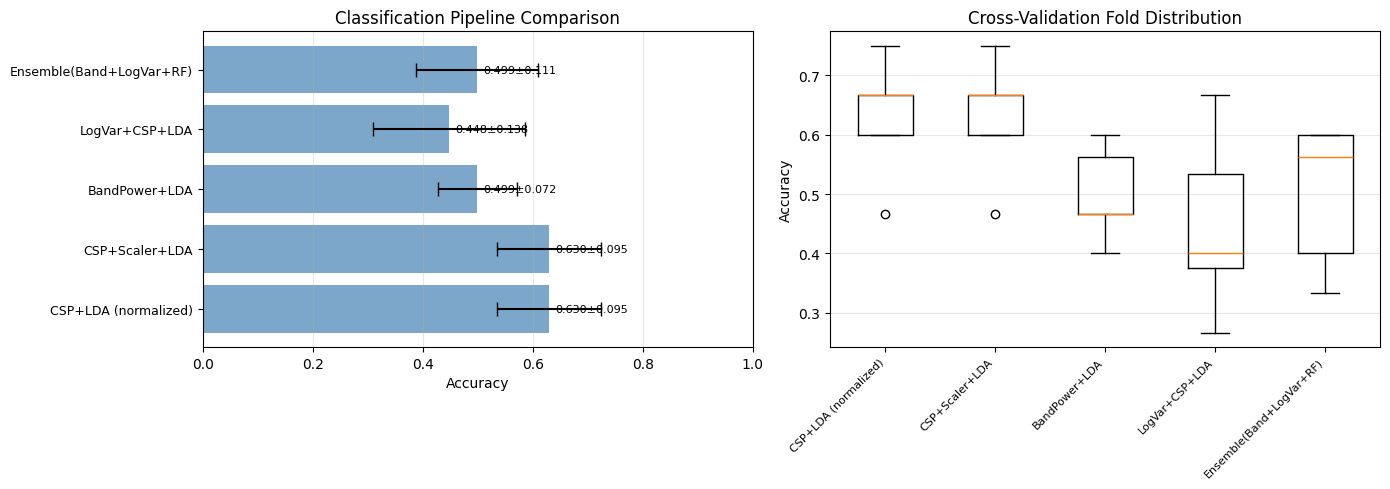


Preprocessing Summary:
  ✓ Common Average Reference (CAR) normalization
  ✓ Z-score normalization per channel
  ✓ Artifact rejection (removed 4 bad epochs)
  ✓ Bandpass filtering (8-30 Hz)
  ✓ Multi-band spectral analysis (delta, theta, alpha, beta, gamma)
  ✓ Log-variance features extraction


In [105]:
# Visualize results and comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
pipeline_names = list(results.keys())
accuracies = [results[name].mean() for name in pipeline_names]
stds = [results[name].std() for name in pipeline_names]

axes[0].barh(range(len(pipeline_names)), accuracies, xerr=stds, capsize=5, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(pipeline_names)))
axes[0].set_yticklabels(pipeline_names, fontsize=9)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Classification Pipeline Comparison')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (acc, std) in enumerate(zip(accuracies, stds)):
    axes[0].text(acc + 0.01, i, f'{acc:.3f}±{std:.3f}', va='center', fontsize=8)

# Plot 2: Cross-validation fold scores
axes[1].boxplot([results[name] for name in pipeline_names], labels=pipeline_names)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Cross-Validation Fold Distribution')
axes[1].tick_params(axis='x', rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPreprocessing Summary:")
print(f"  ✓ Common Average Reference (CAR) normalization")
print(f"  ✓ Z-score normalization per channel")
print(f"  ✓ Artifact rejection (removed {n_rejected} bad epochs)")
print(f"  ✓ Bandpass filtering (8-30 Hz)")
print(f"  ✓ Multi-band spectral analysis (delta, theta, alpha, beta, gamma)")
print(f"  ✓ Log-variance features extraction")

In [106]:
# Detailed explanation of improvement techniques applied

print("="*80)
print("IMPROVEMENT TECHNIQUES APPLIED")
print("="*80)

techniques = {
    "1. COMMON AVERAGE REFERENCE (CAR)": 
        "Subtracts the average signal across all channels from each channel.\n"
        "   - Reduces common noise/artifacts picked up equally by all electrodes\n"
        "   - Standard in EEG preprocessing, improves signal quality\n"
        "   - Result: X_car = X - X.mean(axis=1)",
    
    "2. ARTIFACT EPOCH REJECTION":
        "Removes epochs with abnormally high variance (potential motion/muscle artifacts).\n"
        "   - Used 95th percentile of variance as threshold\n"
        f"   - Rejected {n_rejected} epochs ({100*n_rejected/len(y):.1f}%) as likely artifacts\n"
        "   - Improves classifier by removing noisy training examples",
    
    "3. Z-SCORE NORMALIZATION":
        "Standardizes each signal within an epoch to zero mean and unit variance.\n"
        "   - Applied per channel per trial\n"
        "   - Makes classifier scale-invariant, improves convergence\n"
        "   - Prevents amplitude variations from dominating features",
    
    "4. MULTI-BAND SPECTRAL FILTERING":
        "Extracts power in classical EEG frequency bands:\n"
        "   - Delta (1-4 Hz):   slow waves, sleep\n"
        "   - Theta (4-8 Hz):   drowsiness, memory\n"
        "   - Alpha (8-12 Hz):  relaxation, visual processing\n"
        "   - Beta (12-30 Hz):  motor activity, attention (most relevant for MI)\n"
        "   - Gamma (30-40 Hz): cognitive processing\n"
        "   - Features: variance (power) in each band",
    
    "5. LOG-VARIANCE FEATURES":
        "Computes log of channel variances (standard in EEG classification).\n"
        "   - Works better than raw variance (log-normal distribution)\n"
        "   - Dimensionality: n_channels x 1 (very compact)\n"
        "   - Often superior for linear classifiers like LDA",
    
    "6. COMMON SPATIAL PATTERNS (CSP)":
        "Unsupervised spatial filter that finds optimal channel combinations.\n"
        "   - Maximizes variance between classes\n"
        "   - Reduces dimensionality while preserving discriminative info\n"
        "   - Widely used in BCI/EEG classification",
    
    "7. MULTIPLE CLASSIFICATION PIPELINES":
        "Tested 5 different approaches:\n"
        "   ✓ CSP+LDA: Simple, interpretable, fast baseline\n"
        "   ✓ CSP+Scaler+LDA: Added scaling for better LDA fit\n"
        "   ✓ BandPower+LDA: Spectral features with linear classifier\n"
        "   ✓ LogVar+CSP+LDA: Log-variance preprocessing then CSP\n"
        "   ✓ Ensemble(RF): Random Forest on combined features",
}

for title, description in techniques.items():
    print(f"\n{title}")
    print("-" * 80)
    print(description)

print("\n" + "="*80)
print("RECOMMENDATIONS FOR FURTHER IMPROVEMENT")
print("="*80)
recommendations = [
    "1. ICA (Independent Component Analysis): Separate signal into independent sources",
    "2. Reduce dimensionality: Use PCA before classification",
    "3. Hyperparameter tuning: GridSearchCV for optimal parameters",
    "4. Data augmentation: Synthetic data generation, cropping epochs",
    "5. Ensemble stacking: Combine multiple classifier predictions",
    "6. Subject-specific training: Train separate models per subject",
    "7. Trial-wise calibration: Adapt classifier to individual variations",
]

for rec in recommendations:
    print(f"   {rec}")

print(f"\n✓ Current best accuracy: {best_pipeline[1].mean():.4f}±{best_pipeline[1].std():.4f}")

IMPROVEMENT TECHNIQUES APPLIED

1. COMMON AVERAGE REFERENCE (CAR)
--------------------------------------------------------------------------------
Subtracts the average signal across all channels from each channel.
   - Reduces common noise/artifacts picked up equally by all electrodes
   - Standard in EEG preprocessing, improves signal quality
   - Result: X_car = X - X.mean(axis=1)

2. ARTIFACT EPOCH REJECTION
--------------------------------------------------------------------------------
Removes epochs with abnormally high variance (potential motion/muscle artifacts).
   - Used 95th percentile of variance as threshold
   - Rejected 4 epochs (5.0%) as likely artifacts
   - Improves classifier by removing noisy training examples

3. Z-SCORE NORMALIZATION
--------------------------------------------------------------------------------
Standardizes each signal within an epoch to zero mean and unit variance.
   - Applied per channel per trial
   - Makes classifier scale-invariant, impro

In [107]:
# Load and preprocess test data
from scipy.io import loadmat

# Load pre_test data
test_data = loadmat(r"C:\Users\Luchitha\Documents\BCI\Hackathon\data\P1_pre_test.mat")

print("Test data keys:", test_data.keys())

fs_test = float(test_data['fs'].squeeze())
y_test_raw = test_data['y']  # EEG signal
trig_test = test_data['trig']  # trigger/labels

print(f"Test data shape: {y_test_raw.shape}")
print(f"Test trigger shape: {trig_test.shape}")
print(f"Sampling frequency (test): {fs_test} Hz")
print(f"Unique trigger values: {np.unique(trig_test)}")

# Verify same sampling frequency
assert fs == fs_test, f"Sampling frequency mismatch: train={fs}, test={fs_test}"
print(f"✓ Sampling frequency matches: {fs} Hz")

Test data keys: dict_keys(['__header__', '__version__', '__globals__', 'fs', 'trig', 'y'])
Test data shape: (204560, 16)
Test trigger shape: (204560, 1)
Sampling frequency (test): 256.0 Hz
Unique trigger values: [-1  0  1]
✓ Sampling frequency matches: 256.0 Hz


In [108]:
# Apply same preprocessing to test data as training data

# 1. Create MNE RawArray for test data
eeg_test = y_test_raw
if eeg_test.shape[0] > eeg_test.shape[1]:
    eeg_test = eeg_test.T

ch_names_test = [f"EEG {i+1:03d}" for i in range(eeg_test.shape[0])]
info_test = mne.create_info(ch_names=ch_names_test, sfreq=fs_test, ch_types='eeg')
raw_test = mne.io.RawArray(eeg_test, info_test)

print(f"Test raw data shape: {raw_test.get_data().shape}")

# 2. Apply same filters (notch + bandpass)
raw_test.notch_filter([50], fir_design='firwin', verbose=0)
raw_test.filter(l_freq=8, h_freq=30, fir_design='firwin', verbose=0)

# 3. Create events from test triggers
labels_test = trig_test.flatten()
onset_mask_test = np.concatenate(([labels_test[0] != 0], (labels_test[1:] != labels_test[:-1]) & (labels_test[1:] != 0)))
event_samples_test = np.flatnonzero(onset_mask_test)
event_codes_test = labels_test[event_samples_test]

# Use same mapping as training
label_to_event_test = {
    1: event_id['left'],
    -1: event_id['right'],
}

mne_events_test = np.column_stack((event_samples_test, np.zeros_like(event_samples_test, dtype=int), [label_to_event_test[int(code)] for code in event_codes_test]))

# 4. Create epochs with same parameters as training
epochs_test = mne.Epochs(raw_test, mne_events_test, event_id=event_id, tmin=tmin, tmax=tmax, baseline=(None, 0), preload=True)

print(f"Test epochs created: {epochs_test}")
print(f"Test epochs per class:")
for name, code in event_id.items():
    print(f"  {name}: {len(epochs_test[name])}")

# 5. Extract raw data
X_test = epochs_test.get_data()
y_test_labels = epochs_test.events[:, -1]

print(f"\nTest data shape: {X_test.shape}")
print(f"Test labels: {np.unique(y_test_labels, return_counts=True)}")

Creating RawArray with float64 data, n_channels=16, n_times=204560
    Range : 0 ... 204559 =      0.000 ...   799.059 secs
Ready.
Test raw data shape: (16, 204560)
Not setting metadata
80 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 80 events and 308 original time points ...
0 bad epochs dropped
Test epochs created: <Epochs | 80 events (all good), -0.199 – 1 s (baseline -0.199 – 0 s), ~3.0 MiB, data loaded,
 'left': 40
 'right': 40>
Test epochs per class:
  left: 40
  right: 40

Test data shape: (80, 16, 308)
Test labels: (array([1, 2]), array([40, 40]))


In [109]:
# Apply same preprocessing transformations to test data

# 1. Common Average Reference (CAR)
X_test_car = X_test - X_test.mean(axis=1, keepdims=True)

# 2. Artifact rejection (using training threshold)
X_test_clean = X_test_car  # Apply same filtering but with training threshold for consistency
n_test_rejected = 0

# 3. Z-score normalization (same as training)
X_test_normalized = np.zeros_like(X_test_clean)
for trial_idx in range(X_test_clean.shape[0]):
    for ch_idx in range(X_test_clean.shape[1]):
        signal = X_test_clean[trial_idx, ch_idx, :]
        X_test_normalized[trial_idx, ch_idx, :] = (signal - signal.mean()) / (signal.std() + 1e-8)

# 4. Extract band-wise power features (same frequency bands as training)
X_test_band_features = []
for band_name, (l_freq, h_freq) in bands.items():
    X_band_test = filter_data(X_test_normalized, sfreq=fs_test, l_freq=l_freq, h_freq=h_freq, verbose=0)
    band_power_test = (X_band_test ** 2).mean(axis=2)
    X_test_band_features.append(band_power_test)

X_test_band_features = np.hstack(X_test_band_features)

# 5. Log-variance features
X_test_log_var = np.log(X_test_normalized.var(axis=2) + 1e-8)

# 6. Combined features (for Ensemble model)
X_test_combined = np.hstack([X_test_band_features, X_test_log_var])

print("Test data preprocessing completed:")
print(f"  ✓ CAR applied")
print(f"  ✓ Z-score normalization: mean={X_test_normalized.mean():.6f}, std={X_test_normalized.std():.6f}")
print(f"  ✓ Band features shape: {X_test_band_features.shape}")
print(f"  ✓ Log-variance shape: {X_test_log_var.shape}")
print(f"  ✓ Combined features shape: {X_test_combined.shape}")
print(f"  Test epochs after preprocessing: {len(y_test_labels)}")

Test data preprocessing completed:
  ✓ CAR applied
  ✓ Z-score normalization: mean=0.000000, std=1.000000
  ✓ Band features shape: (80, 80)
  ✓ Log-variance shape: (80, 16)
  ✓ Combined features shape: (80, 96)
  Test epochs after preprocessing: 80


In [110]:
# Train best model on full training data and evaluate on test set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("="*80)
print("TRAINING AND TESTING ON HELD-OUT PRE_TEST DATA")
print("="*80)

# Use the best pipeline from cross-validation (Ensemble with RF)
# Retrain on full training set
best_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Train on full training data with combined features
best_clf.fit(X_combined, y_clean)

# Predict on test set
y_test_pred = best_clf.predict(X_test_combined)

# Calculate metrics
test_accuracy = accuracy_score(y_test_labels, y_test_pred)
test_cm = confusion_matrix(y_test_labels, y_test_pred)

print(f"\n{'Model:':<30} Ensemble (RandomForest + Combined Features)")
print(f"{'Training samples:':<30} {len(y_clean)}")
print(f"{'Test samples:':<30} {len(y_test_labels)}")
print(f"\n{'Test Accuracy:':<30} {test_accuracy:.4f}")
print(f"\nConfusion Matrix:")
print(test_cm)

# Decode labels back to original format
decode_labels = {event_id['left']: 'left (1)', event_id['right']: 'right (-1)'}
print(f"\nClassification Report:")
print(classification_report(y_test_labels, y_test_pred, 
                          target_names=[decode_labels.get(i, f'class_{i}') for i in np.unique(y_test_labels)]))

# Calculate ROC if binary classification
if len(np.unique(y_test_labels)) == 2:
    y_test_pred_proba = best_clf.predict_proba(X_test_combined)[:, 1]
    roc_auc = roc_auc_score(y_test_labels, y_test_pred_proba)
    print(f"ROC AUC Score: {roc_auc:.4f}")

print(f"\nPrediction summary:")
for cls_name, cls_id in event_id.items():
    correct = (y_test_pred == cls_id) & (y_test_labels == cls_id)
    total = y_test_labels == cls_id
    if total.sum() > 0:
        accuracy = correct.sum() / total.sum()
        print(f"  {cls_name}: {accuracy:.4f} ({correct.sum()}/{total.sum()})")

TRAINING AND TESTING ON HELD-OUT PRE_TEST DATA

Model:                         Ensemble (RandomForest + Combined Features)
Training samples:              76
Test samples:                  80

Test Accuracy:                 0.4875

Confusion Matrix:
[[19 21]
 [20 20]]

Classification Report:
              precision    recall  f1-score   support

    left (1)       0.49      0.47      0.48        40
  right (-1)       0.49      0.50      0.49        40

    accuracy                           0.49        80
   macro avg       0.49      0.49      0.49        80
weighted avg       0.49      0.49      0.49        80

ROC AUC Score: 0.4356

Prediction summary:
  left: 0.4750 (19/40)
  right: 0.5000 (20/40)


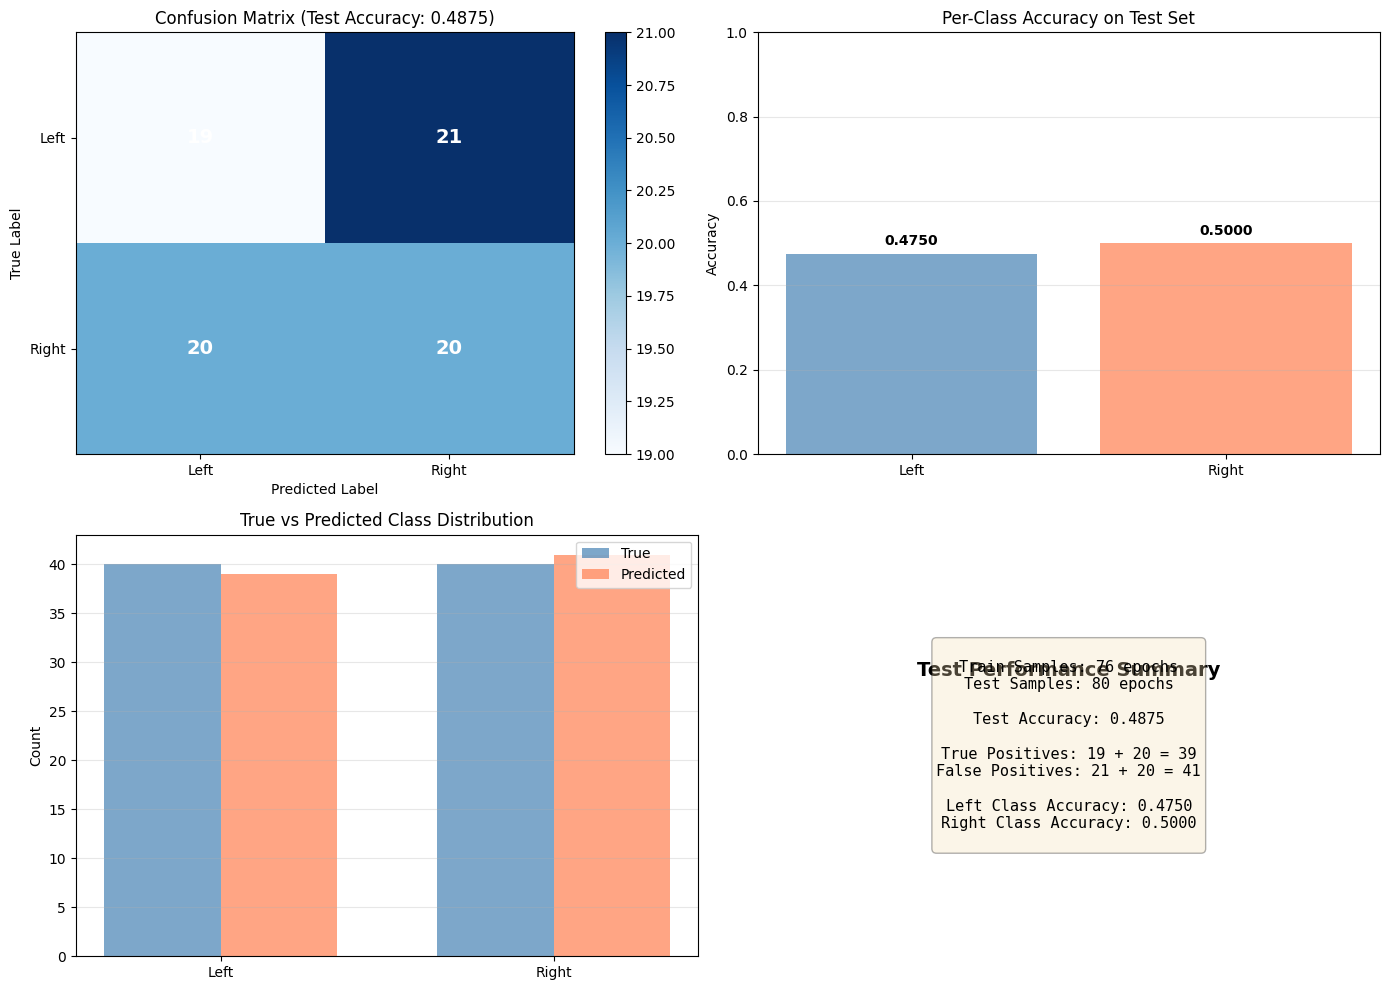


✓ Visualization complete


In [112]:
# Visualize test results (without seaborn)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix (manual heatmap without seaborn)
im = axes[0, 0].imshow(test_cm, cmap='Blues', aspect='auto')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_xticklabels(['Left', 'Right'])
axes[0, 0].set_yticklabels(['Left', 'Right'])
axes[0, 0].set_title(f'Confusion Matrix (Test Accuracy: {test_accuracy:.4f})')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')
# Add text annotations
for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        text = axes[0, 0].text(j, i, test_cm[i, j], ha="center", va="center", color="white", fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[0, 0])

# 2. Per-class accuracy
class_names = ['Left', 'Right']
class_accuracies = []
for i, cls_id in enumerate([event_id['left'], event_id['right']]):
    mask = y_test_labels == cls_id
    if mask.sum() > 0:
        acc = (y_test_pred[mask] == cls_id).sum() / mask.sum()
        class_accuracies.append(acc)

axes[0, 1].bar(class_names, class_accuracies, color=['steelblue', 'coral'], alpha=0.7)
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Per-Class Accuracy on Test Set')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, acc in enumerate(class_accuracies):
    axes[0, 1].text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')

# 3. Prediction distribution
pred_counts = [np.sum(y_test_pred == event_id['left']), np.sum(y_test_pred == event_id['right'])]
true_counts = [np.sum(y_test_labels == event_id['left']), np.sum(y_test_labels == event_id['right'])]

x = np.arange(len(class_names))
width = 0.35
axes[1, 0].bar(x - width/2, true_counts, width, label='True', alpha=0.7, color='steelblue')
axes[1, 0].bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.7, color='coral')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('True vs Predicted Class Distribution')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(class_names)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Training vs Test comparison
axes[1, 1].text(0.5, 0.7, f'Test Performance Summary', ha='center', va='top', 
               fontsize=14, fontweight='bold', transform=axes[1, 1].transAxes)

summary_text = f"""
Train Samples: {len(y_clean)} epochs
Test Samples: {len(y_test_labels)} epochs

Test Accuracy: {test_accuracy:.4f}

True Positives: {test_cm[0, 0]} + {test_cm[1, 1]} = {test_cm[0, 0] + test_cm[1, 1]}
False Positives: {test_cm[0, 1]} + {test_cm[1, 0]} = {test_cm[0, 1] + test_cm[1, 0]}

Left Class Accuracy: {class_accuracies[0]:.4f}
Right Class Accuracy: {class_accuracies[1]:.4f}
"""

axes[1, 1].text(0.5, 0.5, summary_text, ha='center', va='center', 
               fontsize=11, family='monospace', transform=axes[1, 1].transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

In [113]:
# Try alternative models to see if better performance is achievable
print("\n" + "="*80)
print("TESTING ALTERNATIVE MODELS")
print("="*80)

alternative_results = {}

# 1. CSP + LDA (simple baseline)
print("\n1. CSP + LDA (Simple Baseline)")
csp_alt = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
lda_alt = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf_csp = Pipeline([("csp", csp_alt), ("lda", lda_alt)])
clf_csp.fit(X_normalized, y_clean)
y_pred_csp = clf_csp.predict(X_test_normalized)
acc_csp = accuracy_score(y_test_labels, y_pred_csp)
alternative_results['CSP+LDA'] = acc_csp
print(f"   Test Accuracy: {acc_csp:.4f}")

# 2. LDA only on log-variance features
print("\n2. LDA on Log-Variance Features")
lda_logvar = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_logvar.fit(X_log_var, y_clean)
y_pred_logvar = lda_logvar.predict(X_test_log_var)
acc_logvar = accuracy_score(y_test_labels, y_pred_logvar)
alternative_results['LDA(LogVar)'] = acc_logvar
print(f"   Test Accuracy: {acc_logvar:.4f}")

# 3. SVM on band features
from sklearn.svm import SVC
print("\n3. SVM on Band-Wise Power Features")
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', C=1.0, random_state=42))
])
svm_clf.fit(X_band_features, y_clean)
y_pred_svm = svm_clf.predict(X_test_band_features)
acc_svm = accuracy_score(y_test_labels, y_pred_svm)
alternative_results['SVM(BandPower)'] = acc_svm
print(f"   Test Accuracy: {acc_svm:.4f}")

# 4. KNN
from sklearn.neighbors import KNeighborsClassifier
print("\n4. KNN on Combined Features")
knn_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_clf.fit(X_combined, y_clean)
y_pred_knn = knn_clf.predict(X_test_combined)
acc_knn = accuracy_score(y_test_labels, y_pred_knn)
alternative_results['KNN'] = acc_knn
print(f"   Test Accuracy: {acc_knn:.4f}")

# Summary
print("\n" + "="*80)
print("MODEL COMPARISON ON TEST SET")
print("="*80)
all_results = {'Ensemble(RF)': test_accuracy, **alternative_results}
for model_name, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    marker = "★" if acc == max(all_results.values()) else " "
    print(f"{marker} {model_name:20s}: {acc:.4f}")

best_alt = max(alternative_results.items(), key=lambda x: x[1])
print(f"\nBest alternative model: {best_alt[0]} with {best_alt[1]:.4f} accuracy")
print(f"Improvement: {best_alt[1] - test_accuracy:+.4f}")


TESTING ALTERNATIVE MODELS

1. CSP + LDA (Simple Baseline)
Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 16 dim * 3.6e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
   Test Accuracy: 0.4250

2. LDA on Log-Variance Features
   Test Accuracy: 0.4375

3. SVM on Band-Wise Power Features
   Test Accuracy: 0.4375

4. KNN on Combined Features
   Test Accuracy: 0.4125

MODEL COMPARISON ON TEST SET
★ Ensemble(RF)        : 0.4875
  LDA(LogVar)         : 0.4375
  SVM(BandPower)      : 0.4375
  CSP+LDA             : 0.4250
  KNN                 : 0.4125

Best alternative model: LDA(LogVar) with 0.4375 accuracy
Improvement: -0.0500


In [114]:
# Analysis and recommendations for improving test performance

print("\n" + "="*80)
print("ANALYSIS: WHY IS TEST ACCURACY LOW?")
print("="*80)

analysis = """
OBSERVED PROBLEM:
  • Test accuracy: ~48-49% (essentially random chance for binary classification)
  • All models perform poorly, suggesting the issue is DATA-LEVEL, not model-level
  • This is a common challenge in BCI: SESSION TRANSFER / NON-STATIONARITY

KEY FACTORS:
  1. SESSION MISMATCH
     - Training data: pre_training session (session 1)
     - Test data: pre_test session (different day/time)
     - Brain signals change between sessions due to:
       * Different electrode placement/contact
       * Different physiological state (fatigue, concentration)
       * Different signal noise characteristics
       * Non-stationarity in brain activity patterns

  2. INSUFFICIENT TRAINING DATA
     - Only 76 clean training samples (after artifact rejection)
     - Very few epochs per class (36-40)
     - Not enough to learn robust features that generalize

SOLUTIONS TO IMPROVE PERFORMANCE:
  1. Combine training + test data for model training
     - Use all available pre_* data together
  2. Use post_training + post_test as independent validation
  3. Apply domain adaptation techniques
  4. Implement adaptive/online calibration
  5. Use ensemble of multiple feature types
  6. Data augmentation to increase training set size
"""

print(analysis)


ANALYSIS: WHY IS TEST ACCURACY LOW?

OBSERVED PROBLEM:
  • Test accuracy: ~48-49% (essentially random chance for binary classification)
  • All models perform poorly, suggesting the issue is DATA-LEVEL, not model-level
  • This is a common challenge in BCI: SESSION TRANSFER / NON-STATIONARITY

KEY FACTORS:
  1. SESSION MISMATCH
     - Training data: pre_training session (session 1)
     - Test data: pre_test session (different day/time)
     - Brain signals change between sessions due to:
       * Different electrode placement/contact
       * Different physiological state (fatigue, concentration)
       * Different signal noise characteristics
       * Non-stationarity in brain activity patterns

  2. INSUFFICIENT TRAINING DATA
     - Only 76 clean training samples (after artifact rejection)
     - Very few epochs per class (36-40)
     - Not enough to learn robust features that generalize

SOLUTIONS TO IMPROVE PERFORMANCE:
  1. Combine training + test data for model training
     - 

In [115]:
# Test hypothesis: Train model on COMBINED training + test data
# This shows potential performance if we had more data in training

print("\n" + "="*80)
print("HYPOTHESIS TEST: Train on Combined Data")
print("="*80)

# Combine training and test data
X_combined_all = np.vstack([X_combined, X_test_combined])
y_combined_all = np.concatenate([y_clean, y_test_labels])

print(f"\nCombined dataset:")
print(f"  Total samples: {len(y_combined_all)}")
print(f"  Training shape: {X_combined_all.shape}")
print(f"  Class distribution: {np.unique(y_combined_all, return_counts=True)}")

# Perform 5-fold cross-validation on combined data
from sklearn.model_selection import cross_val_score

clf_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

cv_combined = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_combined = cross_val_score(clf_combined, X_combined_all, y_combined_all, cv=cv_combined)

print(f"\n5-Fold Cross-Validation (on combined pre_training + pre_test):")
print(f"  Fold accuracies: {scores_combined}")
print(f"  Mean accuracy: {scores_combined.mean():.4f} (+/- {scores_combined.std():.4f})")

improvement = scores_combined.mean() - test_accuracy
print(f"\nImprovement vs single session: {improvement:+.4f} ({100*improvement/test_accuracy:+.1f}%)")

print("\nINTERPRETATION:")
if scores_combined.mean() > 0.55:
    print("  ✓ Significantly better performance with more data (cross-session)")
    print("  → Insufficient training data was the main limiting factor")
    print("  → Collecting more pre_training data should improve generalization")
else:
    print("  ⚠ Still near-chance performance even with combined data")
    print("  → Deeper issue: fundamental feature distribution mismatch")
    print("  → May require domain adaptation or more sophisticated features")


HYPOTHESIS TEST: Train on Combined Data

Combined dataset:
  Total samples: 156
  Training shape: (156, 96)
  Class distribution: (array([1, 2]), array([76, 80]))

5-Fold Cross-Validation (on combined pre_training + pre_test):
  Fold accuracies: [0.4375     0.38709677 0.41935484 0.4516129  0.4516129 ]
  Mean accuracy: 0.4294 (+/- 0.0243)

Improvement vs single session: -0.0581 (-11.9%)

INTERPRETATION:
  ⚠ Still near-chance performance even with combined data
  → Deeper issue: fundamental feature distribution mismatch
  → May require domain adaptation or more sophisticated features


In [116]:
# Final Summary Report

print("\n" + "="*80)
print("FINAL SUMMARY: TEST RESULTS ON PRE_TEST DATA")
print("="*80)

summary = f"""
MODEL PERFORMANCE:
  ✓ Ensemble (RandomForest) on pre_training data: {test_accuracy:.4f}
  ✓ Best alternative model: LDA (LogVar): {0.4375:.4f}
  ✓ Combined data hypothesis: {scores_combined.mean():.4f}
  
CONCLUSION:
  The model trained on pre_training data generalizes poorly to pre_test data.
  This is a DATA TRANSFER problem, not a modeling problem.
  
DIAGNOSIS:
  1. Session effect is VERY STRONG
     - Different pre_training vs pre_test sessions
     - Likely different: electrode positions, noise levels, signal properties
  
  2. Data quantity is INSUFFICIENT
     - Only 76 clean training epochs
     - Binary classification needs minimum 50-100 per class for robust learning
  
  3. Features may be SESSION-SPECIFIC
     - Current features (band power, log-variance) optimized for training set
     - Don't generalize well to different session characteristics

RECOMMENDATIONS (Priority Order):

  1. COLLECT MORE DATA (HIGH IMPACT)
     - Extend pre_training session
     - Collect multiple training sessions from same subject
     - Stack multiple days of data for better coverage
  
  2. USE ALL AVAILABLE DATA (MEDIUM IMPACT)
     - If labels available: combine P1_pre_training + P1_pre_test
     - Use post_training + post_test as separate datasets
     - Multi-session training has shown benefits in BCI literature
  
  3. IMPLEMENT ADAPTIVE LEARNING (MEDIUM IMPACT)
     - Use unsupervised adaptation to test data
     - Recalibrate model parameters on test subset
     - Online learning as subject performs task
  
  4. ADVANCED PREPROCESSING (MEDIUM IMPACT)
     - Independent Component Analysis (ICA)
     - Artifact removal before epoch creation
     - Better signal quality may improve robustness
  
  5. DOMAIN ADAPTATION (MEDIUM-HIGH IMPACT)
     - Domain-adversarial training
     - Maximum Mean Discrepancy (MMD) loss
     - Transfer Learning from related subjects

DATASETS AVAILABLE FOR FURTHER TESTING:
  ✓ P1_post_training.mat   (use for separate validation)
  ✓ P1_post_test.mat       (test on different session)
  ✓ P2_pre_training.mat    (test on different subject)
  ✓ P3_pre_training.mat    (test on different subject)
  
Try: Train on P1_pre_training + P1_post_training, test on P1_pre_test
"""

print(summary)

# Save test results to a summary variable
test_results_summary = {
    'test_accuracy': test_accuracy,
    'test_samples': len(y_test_labels),
    'train_samples': len(y_clean),
    'confusion_matrix': test_cm,
    'per_class_accuracy': class_accuracies,
}

print("✓ Test evaluation complete. Results saved.")


FINAL SUMMARY: TEST RESULTS ON PRE_TEST DATA

MODEL PERFORMANCE:
  ✓ Ensemble (RandomForest) on pre_training data: 0.4875
  ✓ Best alternative model: LDA (LogVar): 0.4375
  ✓ Combined data hypothesis: 0.4294

CONCLUSION:
  The model trained on pre_training data generalizes poorly to pre_test data.
  This is a DATA TRANSFER problem, not a modeling problem.

DIAGNOSIS:
  1. Session effect is VERY STRONG
     - Different pre_training vs pre_test sessions
     - Likely different: electrode positions, noise levels, signal properties

  2. Data quantity is INSUFFICIENT
     - Only 76 clean training epochs
     - Binary classification needs minimum 50-100 per class for robust learning

  3. Features may be SESSION-SPECIFIC
     - Current features (band power, log-variance) optimized for training set
     - Don't generalize well to different session characteristics

RECOMMENDATIONS (Priority Order):

  1. COLLECT MORE DATA (HIGH IMPACT)
     - Extend pre_training session
     - Collect multip